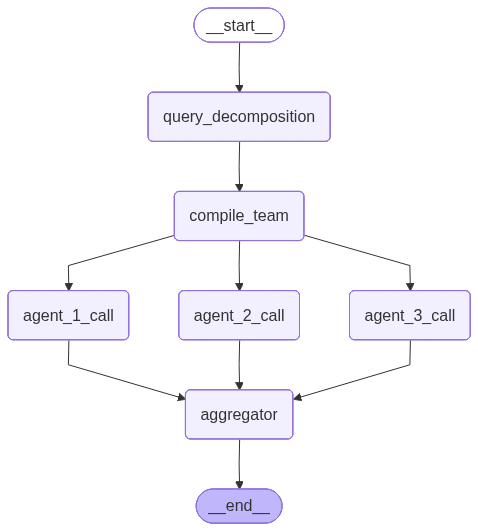

In [1]:
#from .workers import build_worker_graph
from typing import TypedDict, Annotated
from langchain_core.messages import AIMessage
from langgraph.graph import StateGraph, END, START
import operator

class SharedState(TypedDict):
    messages: Annotated[list, operator.add]
    final_response: AIMessage
    team: list[str]

def query_decomposition():
    ...
    
def compile_team():
    ...

def aggregate():
    ...

def call_subgraph():
    ...

def build_overall_graph(preset:list):
    graph = StateGraph(SharedState)
    graph.add_node("query_decomposition", query_decomposition)
    graph.add_node("compile_team", compile_team)
    graph.add_node("aggregator", aggregate)
    for persona in preset:
        graph.add_node(f"{persona}_call", call_subgraph) #-> Из workers.py сделать функцию вызова графа
        graph.add_edge("compile_team", f"{persona}_call")
        graph.add_edge(f"{persona}_call", "aggregator")
    graph.add_edge(START, "query_decomposition")
    graph.add_edge("query_decomposition", "compile_team")
    graph.add_edge("aggregator", END)
    app = graph.compile()
    return app
graph = build_overall_graph(preset=["agent_1", "agent_2", "agent_3"])
graph